In [2]:
import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval
from astropy.io import fits
import scripts.phot_toolkits as phot_tk


%load_ext autoreload
%autoreload 2

The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [5]:
JWST_files                = phot_tk.Pipeline_level_2_data(working_directory = "../../../../../../../../net/vdesk/data2/slagter/JWST_NIRCAM*_#1227_level_2/",)
JWST_files._find_calibrated_filenames(filter='F187N')

In [19]:
JWST_files.find_calibration_versions(JWST_files.cal_file_names[1])

JWST pipeline version             : 2.0.1
Calibration Reference Data System : 13.1.13
CRDS context map                  : jwst_1535.pmap
Read-out pattern                  : BRIGHT2
Number of read-out groups         : 2


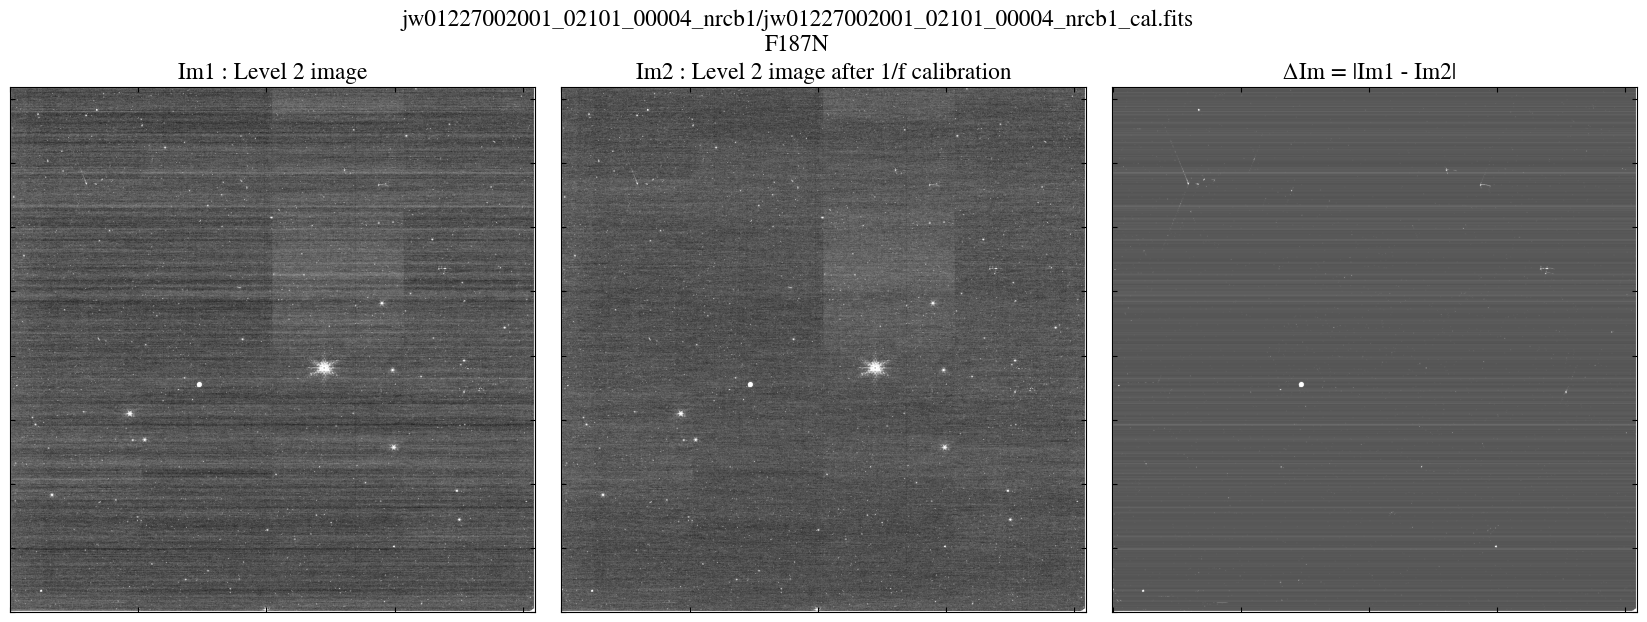

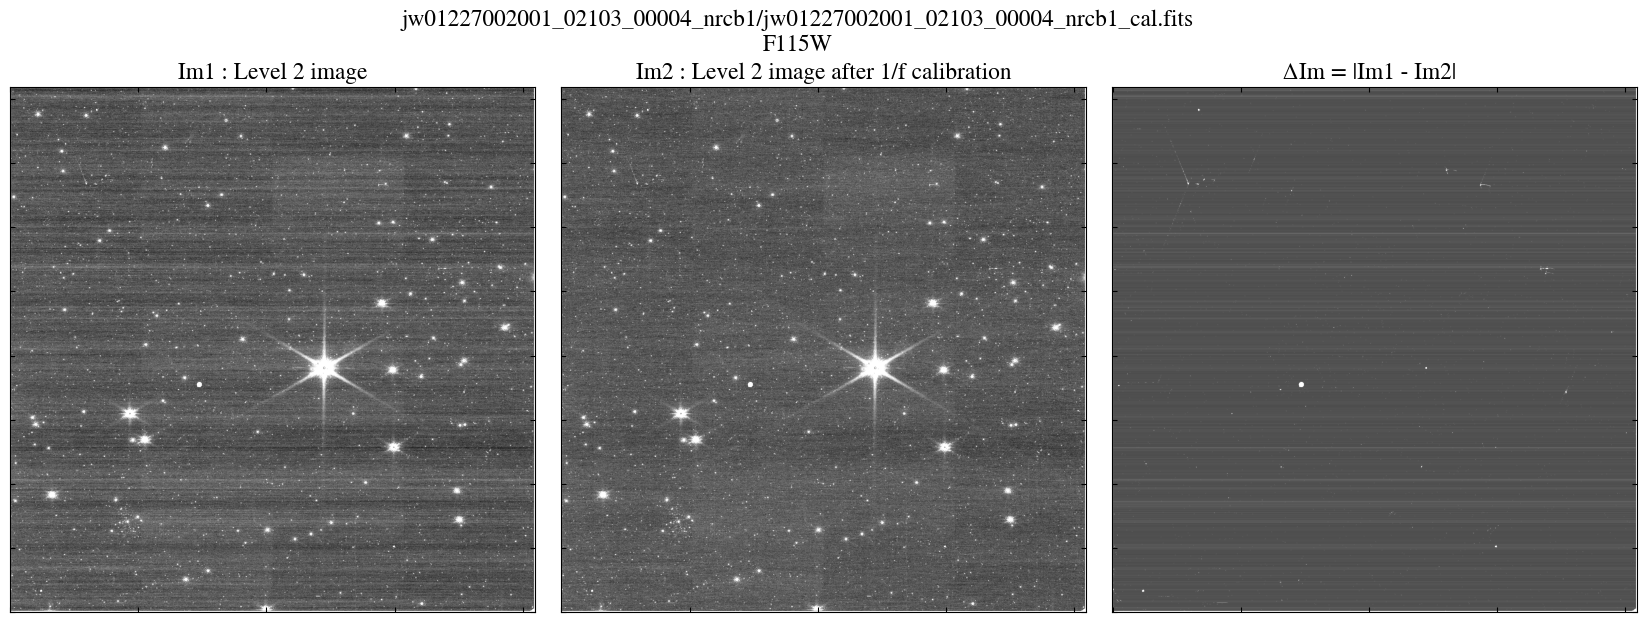

In [25]:
IMAGE_INDEX = 28

JWST_files.show_level2_and_one_over_f_difference(IMAGE_INDEX=28, filter = 'F187N')
JWST_files.show_level2_and_one_over_f_difference(IMAGE_INDEX=28, filter = 'F115W')

In [ ]:
JWST_files.starbug2_aperture_photometry(IMAGE_INDEX             = 28
                                        ,filter                 = 'F187N'
                                        ,remove_background      = True
                                        ,overwrite_always_run   = False)

JWST_files.starbug2_aperture_photometry(IMAGE_INDEX             = 28
                                        ,filter                 = 'F115W'
                                        ,remove_background      = True
                                        ,overwrite_always_run   = False)


['/net/vdesk/data2/slagter/environment_path/SB_venv/bin/starbug2', '-vBD', '../../../../../../../../net/vdesk/data2/slagter/JWST_NIRCAM*_#1227_level_2/F115W/mastDownload/JWST/jw01227002001_02103_00004_nrcb1/jw01227002001_02103_00004_nrcb1_cal_1overf.fits']
Skipping starbug2 run


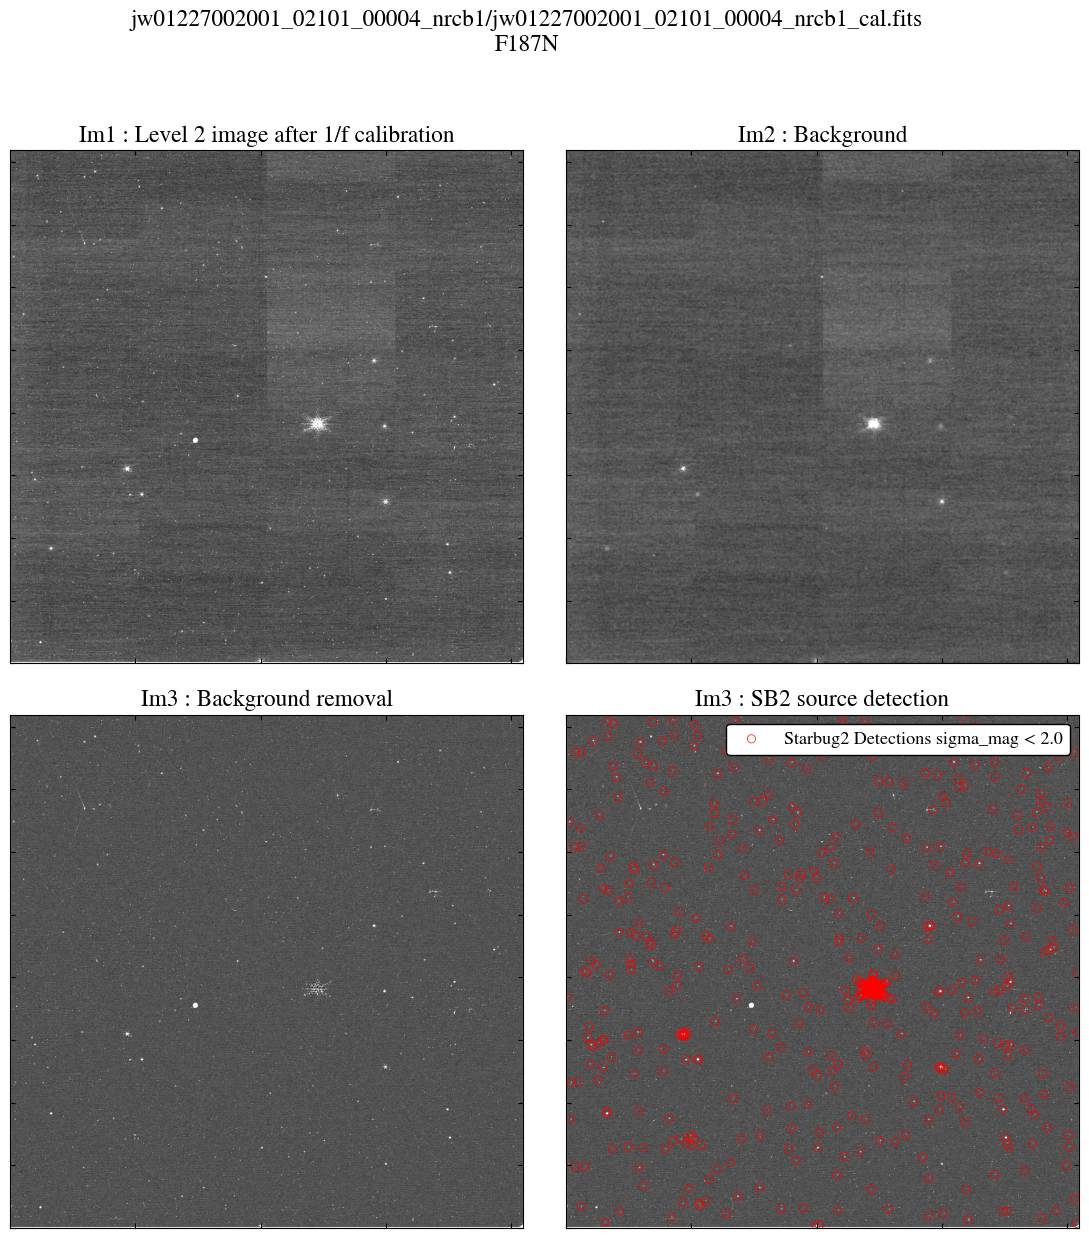

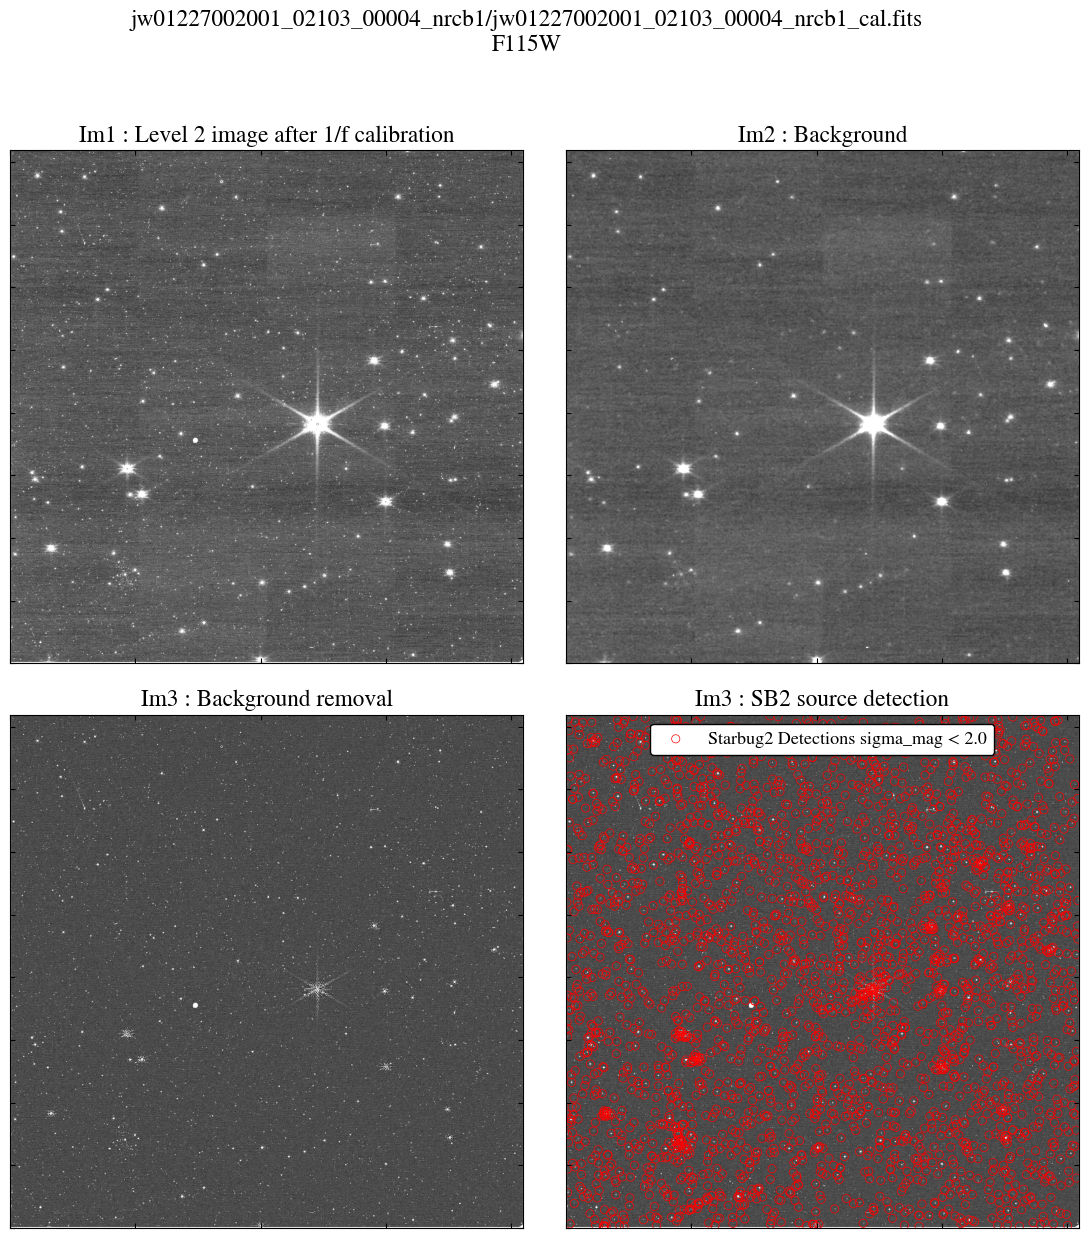

In [37]:
JWST_files.show_one_over_f_SB2(  IMAGE_INDEX            = 28
                                ,filter                 = 'F187N'
                                ,safefig                = True
                                ,detection_sigma        = 2.0)

JWST_files.show_one_over_f_SB2(  IMAGE_INDEX            = 28
                                ,filter                 = 'F115W'
                                ,safefig                = True
                                ,detection_sigma        = 2.0)

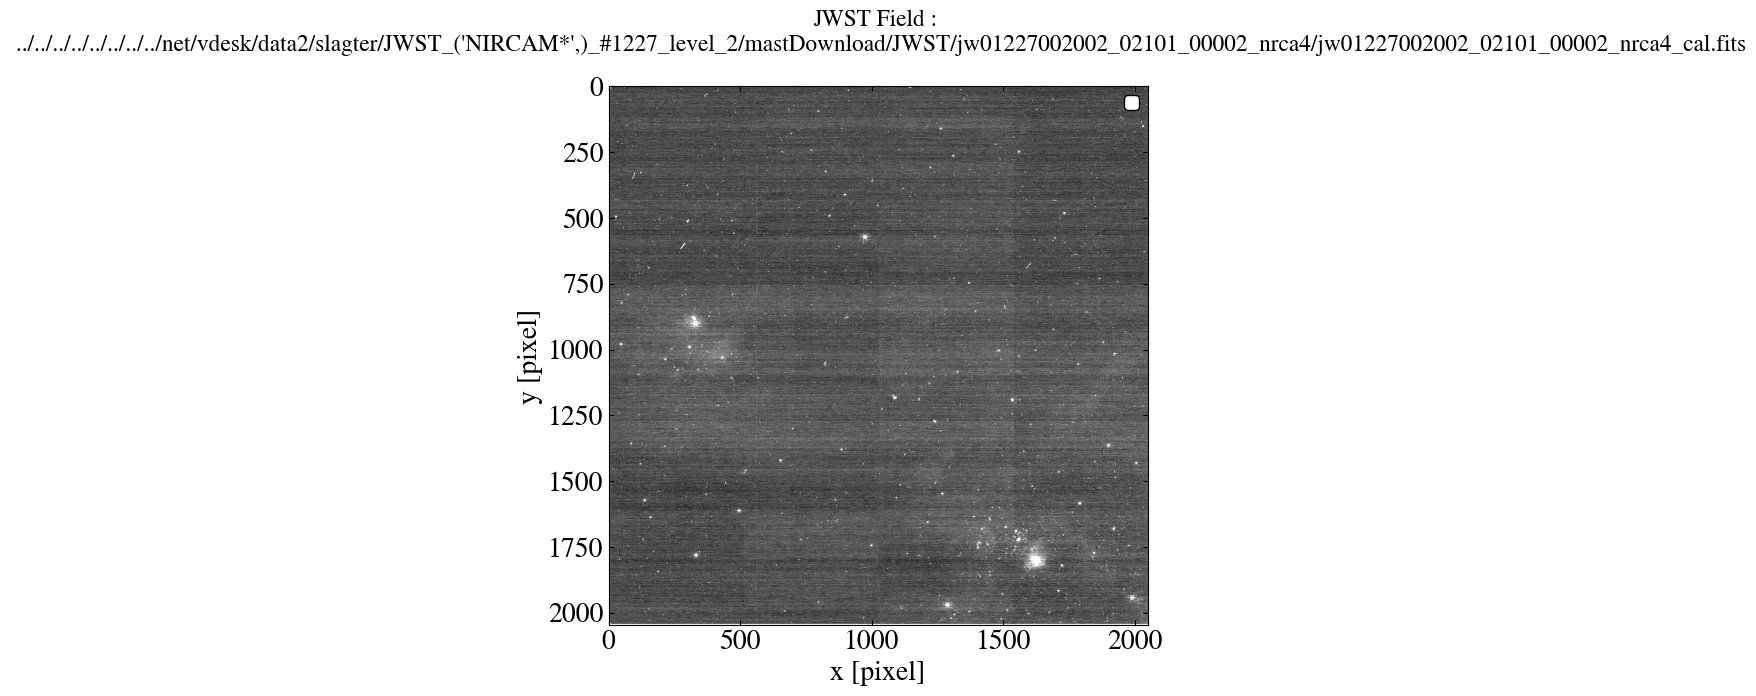

In [30]:
JWST_files.show_detections_over_field(file_index=28, show_detections=False)

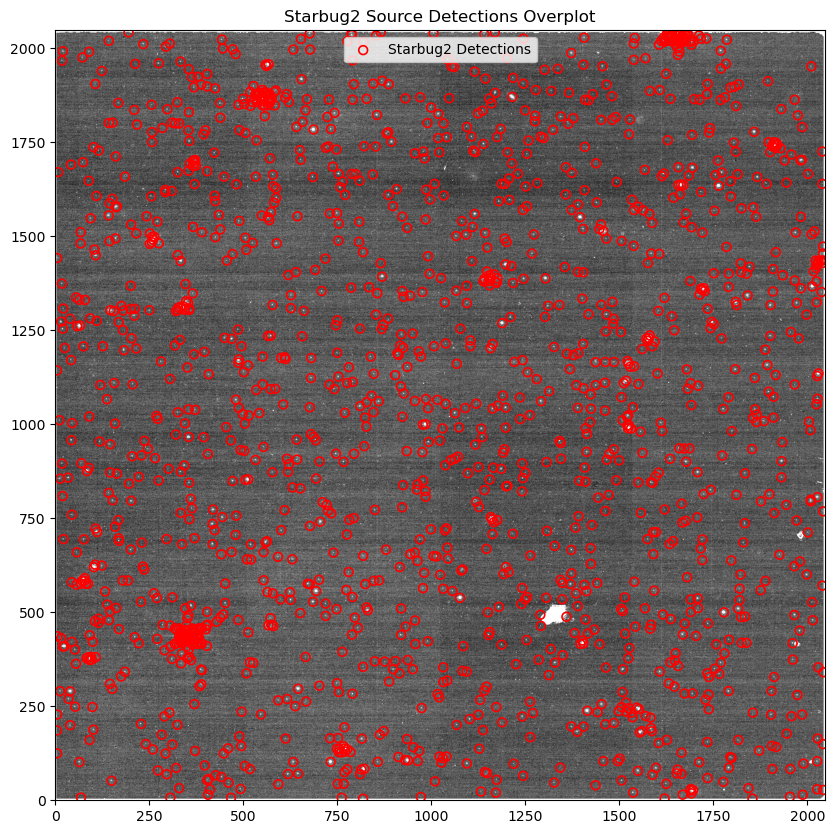

In [8]:
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(science_field)


plt.figure(figsize=(10, 10))
plt.imshow(science_field, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)

# 4. Overplot the source detections as open circles
plt.scatter(x_positions_sources, y_positions_sources, s=40, facecolors='none', edgecolors='red', linewidths=1.2, label='Starbug2 Detections')

plt.legend()
plt.title('Starbug2 Source Detections Overplot')
plt.show()